In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from asyncssh import forward
from sklearn.model_selection import train_test_split
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import re
import copy
from sklearn.decomposition import PCA
import seaborn as sns

In [2]:
data=pd.read_csv('../dihedrals_medoids_1c_20n/Dataset_medoids.csv')

# tokens - top_time model
vocab_top = ['-p', '+p', '-l', '+l', 'd']
vocab_seq = ['1', '2', '3', '4']
vocab = {}
token_id = 0

for t in vocab_top:
    for s in vocab_seq:
        fused = f'{t}_{s}'
        vocab[fused] = token_id
        token_id += 1


def tokenize_sequence(token, vocab):
    tokenized = []
    for i in range(3):  # Since sequences are exactly length 3
        fused_key = token[i]
        tokenized.append(vocab[fused_key])
    return tokenized



# Tokenize data
data['splited_top'] = data['top'].apply(lambda text: re.findall(r'[+-][pl]|d', str(text)))
data['splited_seq'] = data['seq'].apply(lambda text: re.findall(r'1|2|3|4', str(text)))

data['tokens'] = data.apply(lambda row: [f'{top}_{seq}' for top, seq in zip(row['splited_top'], row['splited_seq'])],
                            axis=1)
data['tokenased'] = data.apply(lambda row: tokenize_sequence(row['tokens'], vocab), axis=1)
data=data.drop(['top','seq','tokens', 'splited_top', 'splited_seq'], axis=1)
#data=data[data['sredni_czas']<1000000]
#data=data[data['sredni_czas']>0]
print(data)


         b1_sin    b1_cos    g1_sin    g1_cos    d1_sin    d1_cos    e1_sin  \
0     -0.791544 -0.611113  0.968060  0.250718  0.580845 -0.814014 -0.119964   
1     -0.458650 -0.888617  0.996478  0.083852  0.669520 -0.742794 -0.102098   
2     -0.765596 -0.643322  0.978148  0.207912  0.626196 -0.779666 -0.266229   
3     -0.777585 -0.628778  0.975955  0.217973  0.645724 -0.763571 -0.218825   
4     -0.270600 -0.962692  0.959658  0.281169  0.612217 -0.790690 -0.389445   
...         ...       ...       ...       ...       ...       ...       ...   
25321 -0.917824 -0.396988  0.984989  0.172617  0.527401 -0.849617 -0.284015   
25322 -0.922875 -0.385101  0.988652  0.150226  0.505281 -0.862955 -0.288029   
25323 -0.513391 -0.858155  0.961980  0.273120  0.645324 -0.763909 -0.403386   
25324 -0.749187 -0.662359  0.946705  0.322100  0.996945  0.078111 -0.795473   
25325 -0.791010 -0.611803 -0.513841  0.857886  0.749880 -0.661574 -0.380586   

         e1_cos    z1_sin    z1_cos  ...  K_17_sin 

PCA - do

In [3]:
dih_data=data.drop(['tokenased', 'sredni_czas'], axis=1)
meth_data=data['tokenased']
time=data['sredni_czas']
pca=PCA(n_components=128)
dih_PCA=pca.fit_transform(dih_data)
pca_cols = [f'PC{i+1}' for i in range(128)]
df_dih_PCA=pd.DataFrame(dih_PCA, columns=pca_cols, index=dih_data.index)
data=pd.concat([meth_data, df_dih_PCA], axis=1)
data=pd.concat([data, time], axis=1)
print(data.head(5))
print(np.cumsum(pca.explained_variance_ratio_)[-1])

    tokenased       PC1       PC2       PC3       PC4       PC5       PC6  \
0  [9, 3, 11] -2.441646  0.349468  2.812097  0.106744 -0.816929 -0.776715   
1  [9, 3, 11] -2.137953  0.327482  2.626672  0.007998 -0.893165 -0.707065   
2  [9, 3, 11] -2.539538  0.304393  2.465907  0.255916 -0.413890 -1.017085   
3  [9, 3, 11] -2.279826  0.379774  2.835768  0.084769 -1.004939 -1.157547   
4  [9, 3, 11] -2.247882  0.349240  2.496760  0.142025 -0.804289 -0.806573   

        PC7       PC8       PC9  ...     PC120     PC121     PC122     PC123  \
0 -0.377107 -0.606089  1.218168  ... -0.111672  0.412979  0.333180 -0.362156   
1 -0.685484 -0.777854  1.138404  ... -0.005657  0.366854  0.548199 -0.522533   
2 -0.794180 -0.942226  1.445073  ... -0.293860  0.075922  0.142015 -0.427062   
3 -0.691530 -0.530186  1.198586  ... -0.324434  0.317733  0.494665 -0.440482   
4 -0.722088 -0.609172  0.869552  ... -0.121241  0.439703  0.533528 -0.418740   

      PC124     PC125     PC126     PC127     PC128    s

Tensory

In [6]:
# podział na set nowy
train, test = train_test_split(data, test_size=0.005)
test_fin = data[data['tokenased'].isin(test['tokenased'])].reset_index(drop=True)
train_fin = train[~train['tokenased'].isin(test_fin['tokenased'])].reset_index(drop=True)

X_test=test_fin.drop(['sredni_czas'], axis=1)
Y_test=test_fin['sredni_czas']

train_set, val_set = train_test_split(train_fin, test_size=0.1)
X_train = train_set.drop(['sredni_czas'], axis=1)
X_val = val_set.drop(['sredni_czas'], axis=1)
Y_train = train_set['sredni_czas']
Y_val = val_set['sredni_czas']

# Tensory Y
Y_train_ten=torch.tensor(Y_train.to_numpy(), dtype=torch.float)
Y_val_ten=torch.tensor(Y_val.to_numpy(), dtype=torch.float)
Y_test_ten=torch.tensor(Y_test.to_numpy(), dtype=torch.float)

# przygotowanie danych wejściowych dla modelu token --> time
X_train_tok=X_train['tokenased']
X_val_tok=X_val['tokenased']
X_test_tok=X_test['tokenased']

# przygotowanie danych wejciowych dla modelu kąt --> time
X_train_ang=X_train.drop(['tokenased'], axis=1)
X_val_ang=X_val.drop(['tokenased'], axis=1)
X_test_ang=X_test.drop(['tokenased'], axis=1)

batch=32

# Tensory wejściowe token --> time
X_ten_train_tok=torch.tensor(X_train_tok.tolist(), dtype=torch.long)
X_ten_val_tok=torch.tensor(X_val_tok.tolist(), dtype=torch.long)
X_ten_test_tok=torch.tensor(X_test_tok.tolist(), dtype=torch.long)


# Tensory wejściowe kat --> time
X_ten_train_ang=torch.tensor(X_train_ang.astype('float32').to_numpy(), dtype=torch.float)
X_ten_val_ang=torch.tensor(X_val_ang.astype('float32').to_numpy(), dtype=torch.float)
X_ten_test_ang=torch.tensor(X_test_ang.astype('float32').to_numpy(), dtype=torch.float)

# jednen dataset i dataloader dla połączonego modelu
train_ds_comb=TensorDataset(X_ten_train_tok, X_ten_train_ang, Y_train_ten)
train_loader_comb=DataLoader(train_ds_comb, batch_size=batch, shuffle=True)
val_ds_comb=TensorDataset(X_ten_val_tok, X_ten_val_ang, Y_val_ten)
val_loader_comb=DataLoader(val_ds_comb, batch_size=batch, shuffle=False)
#test_ds_comb=TensorDataset(X_ten_test_tok, X_ten_test_ang, Y_test)
#test_loader_comb=DataLoader(test_ds_comb, batch_size=batch, shuffle=False)

In [7]:
print(f'Długość train setu to: {len(train_set)}, długość test setu to: {len(test_fin)}, % test/train: {(len(test_fin)/len(train_fin))*100}')

Długość train setu to: 20760, długość test setu to: 2259, % test/train: 9.793211080764728


Model

In [13]:
def censored_mse_loss(predictions, targets, cap_value=1000000.0):
    # Calculate standard squared error
    squared_errors = (predictions - targets) ** 2

    # Find where the dataset hit the artificial cap
    capped_mask = (targets >= cap_value)

    # Find where the model correctly guessed it would live longer than the cap
    over_predicted_mask = capped_mask & (predictions > targets)

    # If the simulation stopped at 1M, and the model guessed > 1M, set the error to 0
    squared_errors[over_predicted_mask] = 0.0

    return squared_errors.mean()


# tego nie tykać bo już jest wytrnowany
class GQuadTimeToken(nn.Module):
    def __init__(self, vocab_size=20, embedding_dim=6, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)
        flattened_size = 3 * embedding_dim
        self.fc1 = nn.Linear(flattened_size, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(p=0.15)
        self.fc4 = nn.Linear(32, 8)
        self.fc5 = nn.Linear(8, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        x = embedded.view(embedded.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.dropout(x)
        x = self.fc4(x)
        Model_A_out = x
        return Model_A_out

# tu moge zmieniać ile chce
class GQuadTimeAng(nn.Module):
    def __init__(self):
        super(GQuadTimeAng, self).__init__()
        self.fc1=nn.Linear(128, 64)
        self.fc4=nn.Linear(64,32)
        self.fc6=nn.Linear(32,16)
        self.fc5=nn.Linear(16,1)


        # Activation and drop function
        self.re=nn.ReLU()
        self.drop=nn.Dropout(p=0.2)
        self.bn1=nn.BatchNorm1d(128)


    def forward(self, x):
        x=self.re(self.fc1(x))
        x=self.drop(x)
        x=self.re(self.fc4(x))
        x=self.fc6(x)

        out=x
        return out

class GQuadComb(nn.Module):
    def __init__(self, model_a, model_b):
        super(GQuadComb, self).__init__()
        self.model_a = model_a
        self.model_b = model_b

        self.bnA=nn.BatchNorm1d(8)
        self.bnB=nn.BatchNorm1d(16)


        self.endmodel=nn.Sequential(
            nn.Linear(24, 8),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(8,4),
            nn.ReLU(),
            nn.Linear(4,1),
        )
    def forward(self, input_a, input_b):
        out_a = self.model_a(input_a)
        out_b = self.model_b(input_b)
        out_a = self.bnA(out_a)
        out_b = self.bnB(out_b)

        com_input = torch.cat((out_a, out_b), 1)
        output = self.endmodel(com_input)
        return output

model_a = GQuadTimeToken()
model_a.load_state_dict(torch.load('../modele - wytrenowane/model_toptime_good_ps.pth'))
model_b = GQuadTimeAng()
model_fin=GQuadComb(model_a, model_b)

trainable_parameters = filter(lambda p: p.requires_grad, model_fin.parameters())
#trainable_parameters = model_fin.parameters()
optimizer = torch.optim.Adam(trainable_parameters, lr=0.000075, weight_decay=2.5e-6)
#optimizer = torch.optim.SGD(trainable_parameters, lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)
criterion = nn.MSELoss()
#criterion = nn.HuberLoss(delta=1.0)

epochs = 1000
best_val_loss = float('inf')
how_many=25
counter_dd=0
best_so_far=None
training_loss=[]
val_los=[]
epoch_data=[]

for epoch in range(epochs):
    model_fin.train()
    epoch_train_loss = 0
    epoch_data.append(epoch)
    for batch_X_a, batch_X_b, batch_Y in train_loader_comb:
        optimizer.zero_grad()
        prediction = model_fin(batch_X_a, batch_X_b)
        loss = criterion(prediction, batch_Y.float().unsqueeze(1)) # loss for normal model
        #loss = censored_mse_loss(prediction, batch_Y.float().unsqueeze(1), cap_value=1000000.0) # for log model
        loss.backward()
        optimizer.step()
        epoch_train_loss+=loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader_comb)
    training_loss.append(avg_train_loss)

    model_fin.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X_a, batch_X_b, batch_Y in val_loader_comb:
            prediction = model_fin(batch_X_a, batch_X_b)
            loss = criterion(prediction, batch_Y.float().unsqueeze(1)) # normal model
            #loss = censored_mse_loss(prediction, batch_Y.float().unsqueeze(1), cap_value=1000000.0) # for log model
            val_loss+=loss.item()


    avg_val_loss = val_loss / len(val_loader_comb)
    scheduler.step(avg_val_loss)
    val_los.append(avg_val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter_dd = 0
        best_so_far=copy.deepcopy(model_fin.state_dict())
    else:
        counter_dd += 1

    if epoch %5 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if counter_dd >= how_many:
        print("Early Stopping")
        best_val_loss = np.sqrt(best_val_loss)
        #print(f'Średni błąd Validacji: {best_val_loss:.4f}')
        break

data_graph=pd.DataFrame({
    'Epoch': epoch_data,
    'Training Loss': training_loss,
    'Validation Loss': val_los
} )
model_fin.load_state_dict(best_so_far)


Epoch 000 | Train Loss: 212299212531.7719 | Val Loss: 219925218402.1918
Epoch 005 | Train Loss: 212244646995.6240 | Val Loss: 219907680789.0411
Epoch 010 | Train Loss: 212213129001.4176 | Val Loss: 219816018368.8767
Epoch 015 | Train Loss: 211921681119.2604 | Val Loss: 219500772478.2466
Epoch 020 | Train Loss: 211316927344.4191 | Val Loss: 218807996696.5479
Epoch 025 | Train Loss: 210037598419.4268 | Val Loss: 217326558895.3425
Epoch 030 | Train Loss: 208108631082.6009 | Val Loss: 215331553280.0000
Epoch 035 | Train Loss: 205085587055.2357 | Val Loss: 212142983588.8219
Epoch 040 | Train Loss: 200843618048.3944 | Val Loss: 207851177619.2877
Epoch 045 | Train Loss: 194944740460.8690 | Val Loss: 201802444295.0137
Epoch 050 | Train Loss: 187351249331.4761 | Val Loss: 192303120720.6575
Epoch 055 | Train Loss: 177951530345.3189 | Val Loss: 184202911856.2192
Epoch 060 | Train Loss: 166084128496.6163 | Val Loss: 171484828489.6438
Epoch 065 | Train Loss: 152132688897.5778 | Val Loss: 1569460789

<All keys matched successfully>

--- FINAL EXAM RESULTS ---
On average, the model is off by: 107754.25 time units
R-squared Score (Accuracy proxy): 0.73


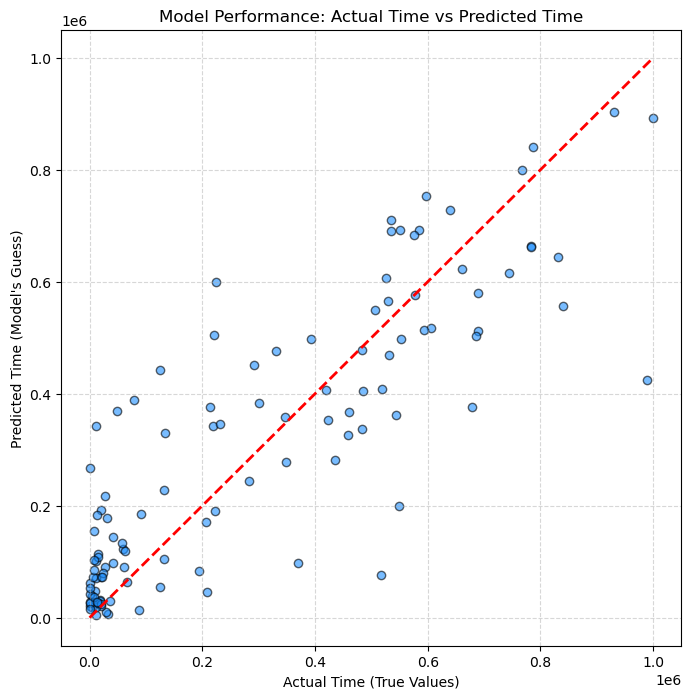

In [14]:
# 1. Put the model into evaluation mode (turns off training features)
model_fin.eval()

# 2. Make predictions on the completely unseen TEST data
with torch.no_grad():
    test_predictions = model_fin(X_ten_test_tok, X_ten_test_ang)

# 3. Convert PyTorch Tensors back to normal Numpy arrays
# (Matplotlib and Sklearn prefer normal arrays)
actuals = Y_test_ten.numpy()
preds = test_predictions.numpy()
df_preds=pd.DataFrame({
    'Tokens': [tuple(x) for x in X_ten_test_tok.numpy()],
    'Predictions':preds.flatten(),
    'Actuals':actuals.flatten()
})

zest=df_preds.groupby(['Tokens']).agg(
    avg_preds=('Predictions','mean'),
    median_preds=('Predictions','median'),
    actuals=('Actuals','mean')
)

#preds=zest['median_preds']
preds=zest['avg_preds']
actuals=zest['actuals']

#preds = (preds * Y_STD) + Y_MEAN
#actuals = (actuals * Y_STD) + Y_MEAN

#actuals = 1000000 * actuals
#preds = 1000000 * preds

# if using np.log1p()
#actuals=np.expm1(actuals)
#preds=np.expm1(preds)

# 4. Calculate "Human-Readable" Scores
# MAE (Mean Absolute Error): On average, how many units of time is the prediction wrong by?
mae = mean_absolute_error(actuals, preds)

# R2 Score: A percentage of how well the model fits the data (1.0 is perfect, 0.0 is terrible)
r2 = r2_score(actuals, preds)

print("--- FINAL EXAM RESULTS ---")
print(f"On average, the model is off by: {mae:.2f} time units")
print(f"R-squared Score (Accuracy proxy): {r2:.2f}")

# 5. Draw the "Actual vs. Predicted" Plot
plt.figure(figsize=(8, 8))
plt.scatter(actuals, preds, alpha=0.6, color='dodgerblue', edgecolors='k')

# Draw a red diagonal line. If the model is perfect, all blue dots will sit exactly on this red line.
min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# Make the plot look nice
plt.title("Model Performance: Actual Time vs Predicted Time")
plt.xlabel("Actual Time (True Values)")
plt.ylabel("Predicted Time (Model's Guess)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Test - surowy

--- FINAL EXAM RESULTS ---
On average, the model is off by: 115487.81 time units
R-squared Score (Accuracy proxy): 0.67


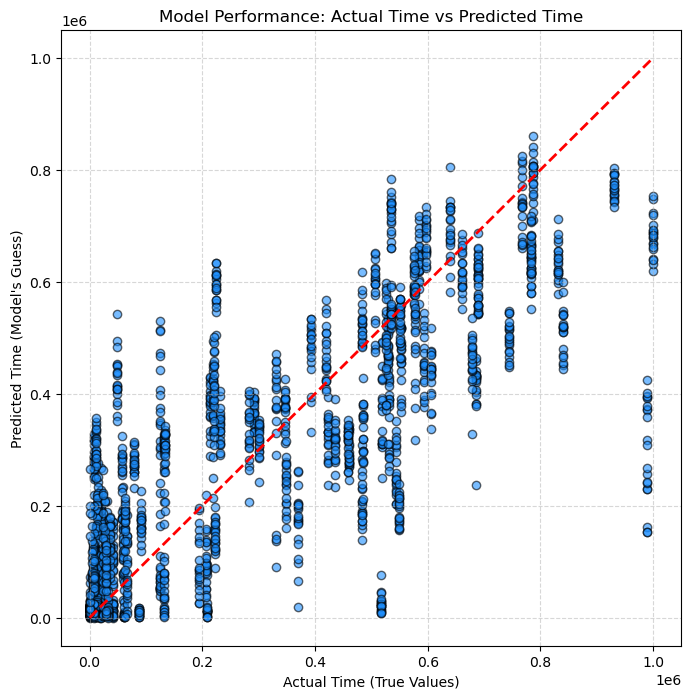

In [10]:
# 1. Put the model into evaluation mode (turns off training features)
model_fin.eval()

# 2. Make predictions on the completely unseen TEST data
with torch.no_grad():
    test_predictions = model_fin(X_ten_test_tok, X_ten_test_ang)

# 3. Convert PyTorch Tensors back to normal Numpy arrays
# (Matplotlib and Sklearn prefer normal arrays)
actuals = Y_test_ten.numpy()
preds = test_predictions.numpy()
df_preds=pd.DataFrame({
    'Tokens': [tuple(x) for x in X_ten_test_tok.numpy()],
    'Predictions':preds.flatten(),
    'Actuals':actuals.flatten()
})


#preds = (preds * Y_STD) + Y_MEAN
#actuals = (actuals * Y_STD) + Y_MEAN

#actuals = 1000000 * actuals
#preds = 1000000 * preds

# if using np.log1p()
#actuals=np.expm1(actuals)
#preds=np.expm1(preds)

# 4. Calculate "Human-Readable" Scores
# MAE (Mean Absolute Error): On average, how many units of time is the prediction wrong by?
mae = mean_absolute_error(actuals, preds)

# R2 Score: A percentage of how well the model fits the data (1.0 is perfect, 0.0 is terrible)
r2 = r2_score(actuals, preds)

print("--- FINAL EXAM RESULTS ---")
print(f"On average, the model is off by: {mae:.2f} time units")
print(f"R-squared Score (Accuracy proxy): {r2:.2f}")

# 5. Draw the "Actual vs. Predicted" Plot
plt.figure(figsize=(8, 8))
plt.scatter(actuals, preds, alpha=0.6, color='dodgerblue', edgecolors='k')

# Draw a red diagonal line. If the model is perfect, all blue dots will sit exactly on this red line.
min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# Make the plot look nice
plt.title("Model Performance: Actual Time vs Predicted Time")
plt.xlabel("Actual Time (True Values)")
plt.ylabel("Predicted Time (Model's Guess)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Rozkład dystrybucji predykcji dla jednego punktu

          Tokens   Predictions      Actuals
1110  (1, 11, 3)  551807.56250  535494.5625
1111  (1, 11, 3)  531780.06250  535494.5625
1112  (1, 11, 3)  535477.87500  535494.5625
1113  (1, 11, 3)  593350.18750  535494.5625
1114  (1, 11, 3)  543318.00000  535494.5625
1115  (1, 11, 3)  589735.50000  535494.5625
1116  (1, 11, 3)  542546.87500  535494.5625
1117  (1, 11, 3)  543277.31250  535494.5625
1118  (1, 11, 3)  538681.56250  535494.5625
1119  (1, 11, 3)  542222.00000  535494.5625
1120  (1, 11, 3)  516718.12500  535494.5625
1121  (1, 11, 3)  551600.25000  535494.5625
1122  (1, 11, 3)  552111.93750  535494.5625
1123  (1, 11, 3)  547795.81250  535494.5625
1124  (1, 11, 3)  543065.31250  535494.5625
1125  (1, 11, 3)  521844.46875  535494.5625
1126  (1, 11, 3)  556784.00000  535494.5625
1127  (1, 11, 3)  524365.68750  535494.5625
1128  (1, 11, 3)  560305.43750  535494.5625
1129  (1, 11, 3)  543001.68750  535494.5625


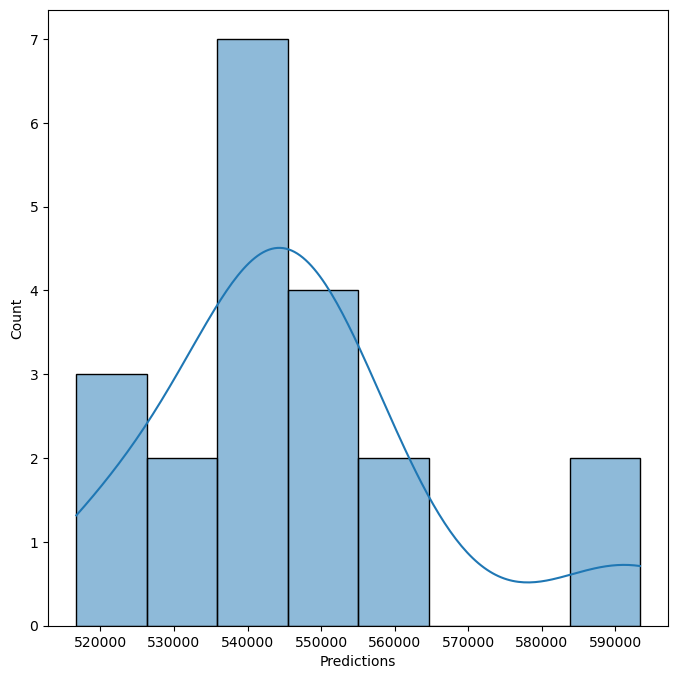

In [11]:
random_df_point=df_preds.sample(n=1, axis=0)
random_df_points=df_preds[df_preds['Tokens']==random_df_point['Tokens'].iloc[0]]
print(random_df_points)
plt.figure(figsize=(8, 8))
sns.histplot(data = random_df_points['Predictions'], kde=True)
plt.show()

Epoche

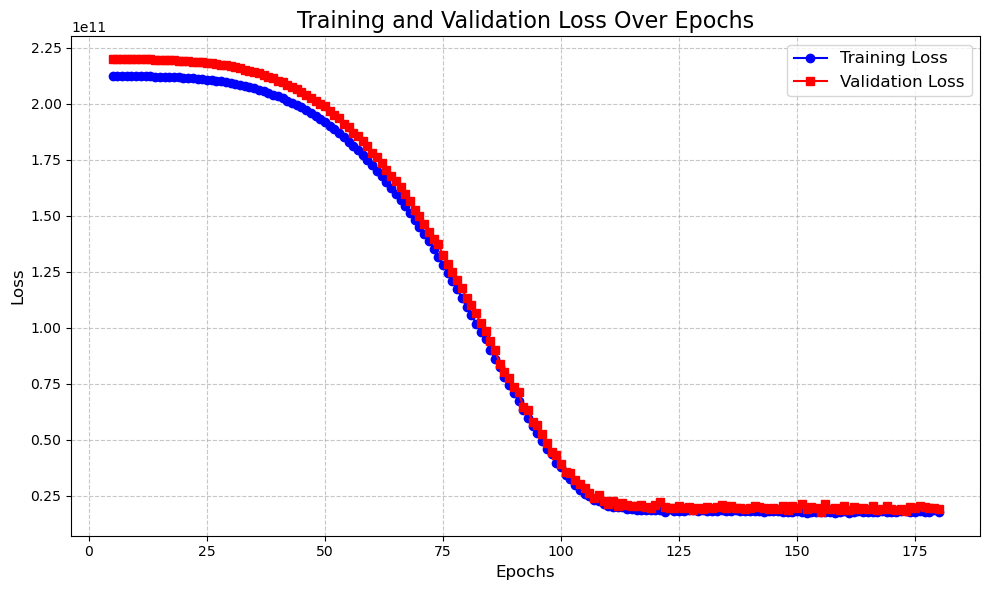

In [12]:
data_graph=data_graph.iloc[5:].reset_index(drop=True)

# Replace these with your actual lists of loss values
epochs = data_graph['Epoch'] # Assuming 15 epochs
train_loss = data_graph['Training Loss']
val_loss = data_graph['Validation Loss']

plt.figure(figsize=(10, 6))

# Plot the lines
plt.plot(epochs, train_loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', color='red', marker='s')

# Add titles and labels
plt.title('Training and Validation Loss Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)

# Add the legend
plt.legend(loc='best', fontsize=12)

# Display the graph
plt.tight_layout()
plt.show()

In [10]:
print(model_fin.state_dict())

OrderedDict({'model_a.embedding.weight': tensor([[ 2.2197, -0.2447,  0.8704, -0.4848,  0.2764,  1.2795],
        [ 1.8616, -0.1259,  1.0282, -0.5296, -0.6427,  0.3426],
        [ 1.1802,  0.1290,  0.5646, -1.0074, -0.5730, -0.6557],
        [-0.0997, -0.0874,  1.0706, -1.3959, -0.6795, -1.7145],
        [ 2.6693, -0.2063, -0.8667,  2.6261,  2.0984, -0.5933],
        [ 0.0989, -0.3099, -2.8613,  0.6526,  1.3685, -1.1823],
        [ 2.4170,  1.4842,  0.9004, -0.6815,  1.6528, -0.7576],
        [ 0.7054,  1.1326, -0.7590, -1.8326,  2.2262, -0.6721],
        [-0.2162, -2.1956, -0.3396,  1.8451,  2.1760, -2.2273],
        [-1.2339,  0.5981,  1.1716, -0.0615,  1.6154, -1.3270],
        [-0.5512,  1.5221,  1.5415,  0.6738,  1.5028,  0.1909],
        [-1.3807,  0.7102,  0.2643,  0.2331,  0.0804, -0.1058],
        [-0.8169, -3.0922,  0.3332,  0.0181,  0.5374,  2.3606],
        [-1.6875, -0.6491,  2.1037, -0.6603,  0.0543, -1.0673],
        [-1.9582, -0.9133, -0.2206,  0.0736, -1.7132, -0.6785],

In [24]:
print(df_preds)

           Tokens    Predictions   Actuals
0     (19, 5, 18)  616598.062500  733780.0
1     (19, 5, 18)  622866.687500  733780.0
2     (19, 5, 18)  640704.250000  733780.0
3     (19, 5, 18)  624570.687500  733780.0
4     (19, 5, 18)  641686.937500  733780.0
...           ...            ...       ...
3543    (9, 2, 1)   64326.757812    1000.0
3544    (9, 2, 1)   97227.585938    1000.0
3545    (9, 2, 1)   58924.156250    1000.0
3546    (9, 2, 1)   53201.671875    1000.0
3547    (9, 2, 1)   48845.671875    1000.0

[3548 rows x 3 columns]


In [14]:
torch.save(model_fin.state_dict(), '../modele - wytrenowane/endmodel_struct_PCAangel.pth')